In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("corona_tested_individuals.csv")

df

C:\Users\jeeva\AppData\Local\Temp\ipykernel_23672\2330322250.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("corona_tested_individuals.csv")


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
...,...,...,...,...,...,...,...,...,...,...
278843,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,NaN,NaN,Other
278844,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,NaN,NaN,Other
278845,2020-03-11,0.0,0.0,0.0,0.0,0.0,positive,NaN,NaN,Contact with confirmed
278846,2020-03-11,0.0,0.0,0.0,0.0,0.0,other,NaN,NaN,Other


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB


In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = df.drop(columns=['corona_result', 'test_date'])
X = pd.get_dummies(X, columns=['age_60_and_above', 'gender', 'test_indication'], drop_first=True)
X = X.fillna(0)
df['corona_result'] = df['corona_result'].replace('other', 'negative')
df['corona_result'] = df['corona_result'].map({'negative': 0, 'positive': 1})
y = df["corona_result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual keys:", y_test.values)


Predictions: [0 0 0 ... 0 0 0]
Actual keys: [0 0 0 ... 0 0 0]


In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[78563   746]
 [ 2317  2029]]


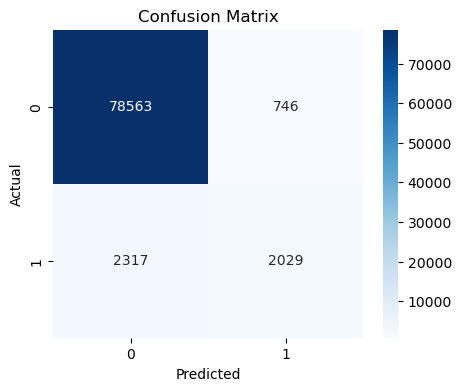

In [7]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.9633853326161018


In [9]:
from sklearn.metrics import precision_score

precision = precision_score(

    y_test,

    y_pred

)

print(precision)

0.7311711711711711


In [10]:
from sklearn.metrics import recall_score

recall = recall_score(

    y_test,

    y_pred

)

print(recall)

0.4668660837551772


In [11]:
from sklearn.metrics import f1_score

f1 = f1_score(

    y_test,

    y_pred

)

print(f1)

0.5698637831765202


In [12]:
probability = model.predict_proba(X_test)

print(probability)

[[0.98738935 0.01261065]
 [0.98271104 0.01728896]
 [0.98738935 0.01261065]
 ...
 [0.98738935 0.01261065]
 [0.98271104 0.01728896]
 [0.98271104 0.01728896]]


In [13]:
from sklearn.metrics import roc_curve

from sklearn.metrics import auc

In [14]:
probability = model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(

    y_test,

    probability

)

roc_auc = auc(

    fpr,

    tpr

)

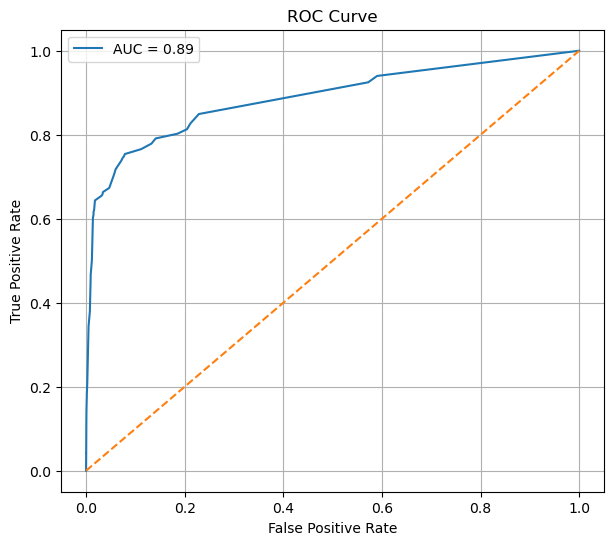

In [15]:
plt.figure(figsize=(7,6))
plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.2f}"

)

plt.plot(

    [0,1],

    [0,1],

    '--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [16]:
pred_05=(probability>=0.5).astype(int)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred_05))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     79309
           1       0.73      0.47      0.57      4346

    accuracy                           0.96     83655
   macro avg       0.85      0.73      0.78     83655
weighted avg       0.96      0.96      0.96     83655



In [18]:
pred_03=(probability>=0.3).astype(int)
print(classification_report(y_test,pred_03))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     79309
           1       0.70      0.60      0.65      4346

    accuracy                           0.97     83655
   macro avg       0.84      0.79      0.81     83655
weighted avg       0.96      0.97      0.96     83655



In [19]:
pred_07=(probability>=0.7).astype(int)
print(classification_report(y_test,pred_07))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     79309
           1       0.79      0.31      0.45      4346

    accuracy                           0.96     83655
   macro avg       0.88      0.65      0.71     83655
weighted avg       0.95      0.96      0.95     83655



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('corona_tested_individuals.csv') 

df['corona_result'] = df['corona_result'].astype(str).str.strip().str.lower()


df['corona_result'] = df['corona_result'].replace('other', 'negative')
df['corona_result'] = df['corona_result'].map({'negative': 0, 'positive': 1})


df = df.dropna(subset=['corona_result'])
y = df["corona_result"].astype(int)


feature_cols = ['age_60_and_above', 'gender', 'test_indication']
X = df[feature_cols].copy()


X = pd.get_dummies(X, columns=feature_cols, drop_first=True)
X = X.fillna(0)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)


y_pred = knn_model.predict(X_test_scaled)


print("--- Execution Successful ---")
print(f"Total training samples: {X_train.shape[0]}")
print(f"Total testing samples: {X_test.shape[0]}")
print("\nFirst 20 Predictions:\n", y_pred[:20])
print("\nFirst 20 Actual Classes:\n", y_test.values[:20])


C:\Users\jeeva\AppData\Local\Temp\ipykernel_23672\791794283.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('corona_tested_individuals.csv')


--- Execution Successful ---
Total training samples: 195193
Total testing samples: 83655

First 20 Predictions:
 [0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]

First 20 Actual Classes:
 [0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]


In [30]:

distances, indices = knn_model.kneighbors(X_test_scaled)

print("Distances to 5 nearest neighbors for first 5 test rows:\n", distances[:5])


Distances to 5 nearest neighbors for first 5 test rows:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
